In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import zipfile

In [43]:
with zipfile.ZipFile('zippedData/im.db.zip', 'r') as z:
    z.extractall('zippedData/')

In [44]:
con = sqlite3.connect('zippedData/im.db')
cur = con.cursor()

In [82]:
bom = pd.read_csv('zippedData/bom.movie_gross.csv.gz', compression='gzip')
bom

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [45]:
cur=con.cursor()

In [48]:
cur.execute("SELECT name FROM sqlite_master WHERE type='table'");
print(cur.fetchall())


[('movie_basics',), ('directors',), ('known_for',), ('movie_akas',), ('movie_ratings',), ('persons',), ('principals',), ('writers',)]


In [50]:
cur.execute("SELECT * FROM movie_akas");
cur.fetchall()

[('tt0369610', 10, 'Джурасик свят', 'BG', 'bg', None, None, 0.0),
 ('tt0369610', 11, 'Jurashikku warudo', 'JP', None, 'imdbDisplay', None, 0.0),
 ('tt0369610',
  12,
  'Jurassic World: O Mundo dos Dinossauros',
  'BR',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610',
  13,
  'O Mundo dos Dinossauros',
  'BR',
  None,
  None,
  'short title',
  0.0),
 ('tt0369610', 14, 'Jurassic World', 'FR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 15, 'Jurassic World', 'GR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 16, 'Jurassic World', 'IT', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 17, 'Jurski svijet', 'HR', None, 'imdbDisplay', None, 0.0),
 ('tt0369610', 18, "Olam ha'Yura", 'IL', 'he', 'imdbDisplay', None, 0.0),
 ('tt0369610',
  19,
  'Jurassic World: Mundo Jurásico',
  'MX',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610',
  1,
  'Jurassic World: Sauruste maailm',
  'EE',
  None,
  'imdbDisplay',
  None,
  0.0),
 ('tt0369610', 20, 'Jurassic World', 'SE', None, 'im

In [51]:
df_ratings=pd.read_sql_query('''SELECT * FROM movie_ratings''',con)
print(df_ratings)

         movie_id  averagerating  numvotes
0      tt10356526            8.3        31
1      tt10384606            8.9       559
2       tt1042974            6.4        20
3       tt1043726            4.2     50352
4       tt1060240            6.5        21
...           ...            ...       ...
73851   tt9805820            8.1        25
73852   tt9844256            7.5        24
73853   tt9851050            4.7        14
73854   tt9886934            7.0         5
73855   tt9894098            6.3       128

[73856 rows x 3 columns]


In [52]:
df_aka=pd.read_sql_query('''SELECT * FROM movie_akas''',con)
print(df_aka)

         movie_id  ordering                                    title region  \
0       tt0369610        10                            Джурасик свят     BG   
1       tt0369610        11                        Jurashikku warudo     JP   
2       tt0369610        12  Jurassic World: O Mundo dos Dinossauros     BR   
3       tt0369610        13                  O Mundo dos Dinossauros     BR   
4       tt0369610        14                           Jurassic World     FR   
...           ...       ...                                      ...    ...   
331698  tt9827784         2                       Sayonara kuchibiru   None   
331699  tt9827784         3                            Farewell Song    XWW   
331700  tt9880178         1                              La atención   None   
331701  tt9880178         2                              La atención     ES   
331702  tt9880178         3                            The Attention    XWW   

       language        types   attributes  is_origi

In [54]:
query = '''
SELECT mb.primary_title, mb.genres, mr.averagerating, mr.numvotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mr.numvotes >= 1000
ORDER BY mr.averagerating DESC
'''

df = pd.read_sql(query, con)
df

,primary_title,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,"Drama,History",9.5,6509
4,Peranbu,Drama,9.4,9629
...,...,...,...,...
9612,Smolensk,"Drama,Thriller",1.4,7383
9613,Amazing China,Documentary,1.3,3244
9614,Potato Salad,"Comedy,Horror",1.3,6249
9615,Cumali Ceber: Allah Seni Alsin,Comedy,1.3,36986


In [75]:
print(df.isnull().sum())


primary_title    0
genres           2
averagerating    0
numvotes         0
dtype: int64


In [76]:
df = df.dropna(subset=['genres'])
print(df.shape)

(9615, 4)


In [78]:
df = pd.read_sql(query, con)
df = df.dropna(subset=['genres'])   
df

,primary_title,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,"Drama,History",9.5,6509
4,Peranbu,Drama,9.4,9629
...,...,...,...,...
9612,Smolensk,"Drama,Thriller",1.4,7383
9613,Amazing China,Documentary,1.3,3244
9614,Potato Salad,"Comedy,Horror",1.3,6249
9615,Cumali Ceber: Allah Seni Alsin,Comedy,1.3,36986


In [80]:
query_writers = '''
SELECT p.primary_name, mb.primary_title, mr.averagerating, mr.numvotes
FROM writers w
JOIN persons p ON w.person_id = p.person_id
JOIN movie_basics mb ON w.movie_id = mb.movie_id
JOIN movie_ratings mr ON w.movie_id = mr.movie_id
WHERE mr.numvotes >= 1000
ORDER BY mr.averagerating DESC
LIMIT 20
'''

df_writers = pd.read_sql(query_writers, con)
df_writers

,primary_name,primary_title,averagerating,numvotes
0,Quentin Tarantino,Once Upon a Time ... in Hollywood,9.7,5600
1,Nikoloz Khomasuridze,Ekvtime: Man of God,9.6,2604
2,Lasha Kankava,Ekvtime: Man of God,9.6,2604
3,Karzan Kardozi,I Want to Live,9.6,1339
4,Saman Weeraman,Aloko Udapadi,9.5,6509
5,Saman Weeraman,Aloko Udapadi,9.5,6509
6,Ram,Peranbu,9.4,9629
7,Ram,Peranbu,9.4,9629
8,Ram,Peranbu,9.4,9629
9,Anjana Krishnakumar,Peranbu,9.4,9629


In [83]:
# Cleaning the bom dataset
print(bom.isnull().sum())

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64


In [92]:
# Since 'foreign_gross' has a lot of missing values, we can fill those with 0, assuming that if it's missing, it means the movie didn't earn any foreign gross.
bom['foreign_gross'] = bom['foreign_gross'].fillna(0)

In [93]:
# Now we can drop rows where 'domestic_gross' is null, since those are crucial for our analysis
bom = bom.dropna(subset=['domestic_gross'])

In [94]:
# Studio missing values fill with 'Unknown'
bom['studio'] = bom['studio'].fillna('Unknown')

In [95]:
# Add a new column for total gross
bom['total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [ ]:
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')
bom['domestic_gross'] = pd.to_numeric(bom['domestic_gross'], errors='coerce')

# Now fill and create total_gross after conversion
bom['foreign_gross'] = bom['foreign_gross'].fillna(0)
bom = bom.dropna(subset=['domestic_gross'])
bom['studio'] = bom['studio'].fillna('Unknown')

bom['total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

print(bom.isnull().sum())
print(bom.shape)

title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
total_gross       0
dtype: int64
(3359, 6)


In [97]:
df_merged = pd.merge(df, bom, left_on='primary_title', right_on='title', how='inner')
print(df_merged.shape)
df_merged.head()

(2447, 10)


,primary_title,genres,averagerating,numvotes,title,studio,domestic_gross,foreign_gross,year,total_gross
0,Burn the Stage: The Movie,"Documentary,Music",8.8,2067,Burn the Stage: The Movie,Trafalgar,4200000.0,16100000.0,2018,20300000.0
1,Inception,"Action,Adventure,Sci-Fi",8.8,1841066,Inception,WB,292600000.0,535700000.0,2010,828300000.0
2,Coriolanus,"Drama,History,War",8.7,1347,Coriolanus,Wein.,757000.0,315000.0,2012,1072000.0
3,Coriolanus,"Drama,Thriller,War",6.1,29654,Coriolanus,Wein.,757000.0,315000.0,2012,1072000.0
4,Interstellar,"Adventure,Drama,Sci-Fi",8.6,1299334,Interstellar,Par.,188000000.0,489400000.0,2014,677400000.0


In [98]:
genre_gross = df_merged.groupby('genres')['total_gross'].mean().sort_values(ascending=False).head(10)
print(genre_gross)

genres
Adventure,Drama,Sport        1.276400e+09
Adventure,Fantasy            7.040333e+08
Adventure,Drama,Sci-Fi       6.537500e+08
Action,Adventure,Sci-Fi      5.880021e+08
Action,Comedy,Mystery        5.441000e+08
Action,Adventure,Fantasy     4.399933e+08
Biography,Drama,Musical      4.350000e+08
Adventure,Mystery,Sci-Fi     4.034000e+08
Action,Adventure,Thriller    3.882411e+08
Adventure,Family,Fantasy     3.849875e+08
Name: total_gross, dtype: float64


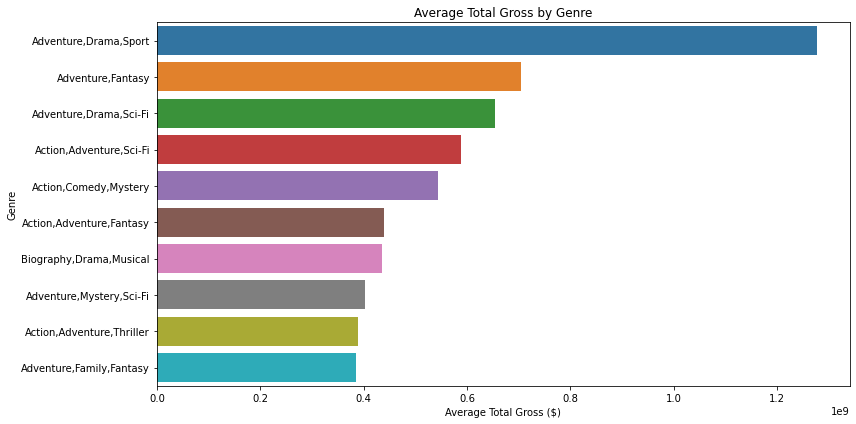

In [99]:
plt.figure(figsize=(12,6))
sns.barplot(x=genre_gross.values, y=genre_gross.index)
plt.title('Average Total Gross by Genre')
plt.xlabel('Average Total Gross ($)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

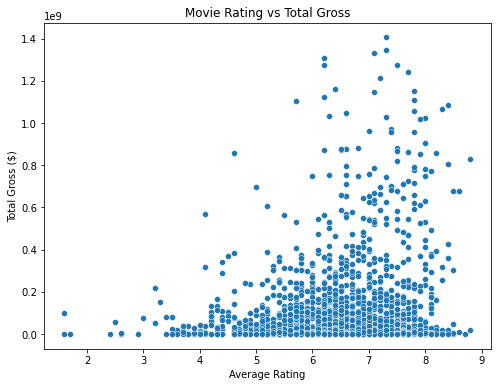

In [101]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merged, x='averagerating', y='total_gross')
plt.title('Movie Rating vs Total Gross')
plt.xlabel('Average Rating')
plt.ylabel('Total Gross ($)')
plt.show()

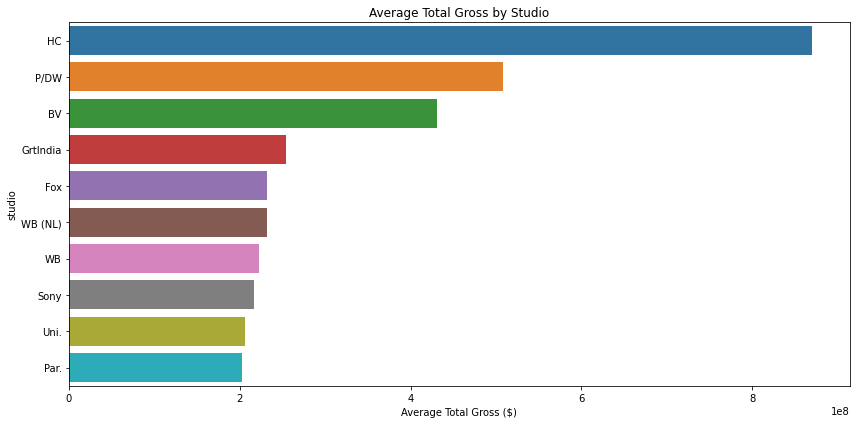

In [102]:
studio_gross = df_merged.groupby('studio')['total_gross'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=studio_gross.values, y=studio_gross.index)
plt.title('Average Total Gross by Studio')
plt.xlabel('Average Total Gross ($)')
plt.tight_layout()
plt.show()